# Session 5 Lecture/Lab: Object Detection & Optical Character Recognition


- Try to read car plate using OpenCV and Tesseract

- Improve car license detection plates using a fine-tuned YOLOv8n model

- Applies OCR with Tesseract to extract text from plates

- Evaluates the system's performance (per-plate detection + OCR accuracy)

- Try another OCR like EASYOCR

# 1  Setup


In [ ]:
!pip -q install ultralytics pytesseract opencv-python tqdm easyocr


import cv2, json, os, random, glob, itertools, math, numpy as np, pandas as pd
from pathlib import Path
from tqdm import tqdm
from matplotlib import pyplot as plt
import pytesseract
from ultralytics import YOLO
from datasets import load_dataset
import easyocr



In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


# 2  Load Dataset I ALREADY DID EVERYTHING FOR YOU, but for your information

- Download the dataset from https://huggingface.co/datasets/keremberke/license-plate-object-detection

- Unzip the free folder (test, train, valid)

- Organise into 2 folders images labels and inside of each it should be train/ valid/ test/

- You have to transform the labels COCO format into a YOLO format

- Import the data to google colab using google drive



In [ ]:
from google.colab import drive
drive.mount('/content/drive/')  # Mount to a different directory


Mounted at /content/drive/


In [ ]:
!ls /content/drive/MyDrive/Plates/

data.yaml  images  labels


**First, have a look at one random image**

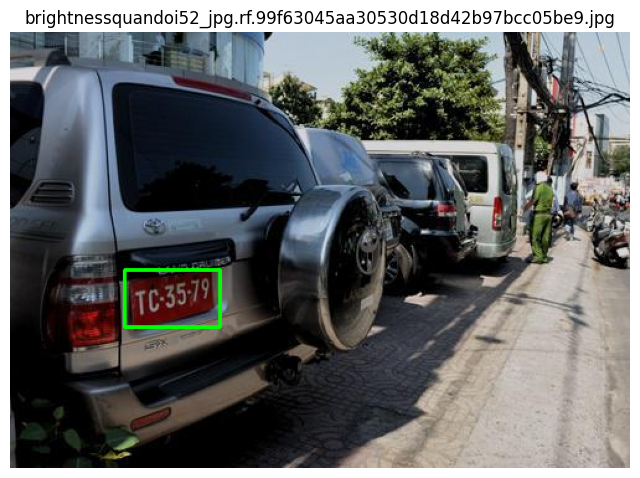

In [ ]:
import json

# Define paths
json_path = "/content/drive/MyDrive/Plates/labels/train/_annotations.coco.json"
image_dir = "/content/drive/MyDrive/Plates/images/train/"

# Load the COCO annotations
with open(json_path) as f:
    coco = json.load(f)

# Build dicts
image_id_to_filename = {img["id"]: img["file_name"] for img in coco["images"]}
annotations_by_image = {}
for ann in coco["annotations"]:
    img_id = ann["image_id"]
    annotations_by_image.setdefault(img_id, []).append(ann)

# Pick a random image with at least 1 annotation
img_id = random.choice([k for k, v in annotations_by_image.items() if len(v) > 0])
filename = image_id_to_filename[img_id]
image_path = os.path.join(image_dir, filename)

# Load image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw boxes
for ann in annotations_by_image[img_id]:
    x, y, w, h = ann["bbox"]
    x1, y1, x2, y2 = int(x), int(y), int(x + w), int(y + h)
    cv2.rectangle(img, (x1, y1), (x2, y2), color=(0,255,0), thickness=2)

# Show image
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title(filename)
plt.show()

**Convert COCO JSON to YOLO TXT (one-time)**

I did it for you, so you do not need to do it

In [ ]:
'''
from pathlib import Path
from tqdm import tqdm

ROOT   = Path("/content/drive/MyDrive/Plates")   # dataset root
SPLITS = ["train", "valid", "test"]              # folder names

def coco_to_yolo(coco_json_path, split):
    """Convert one COCO file to YOLO TXT files (single-class)."""
    with open(coco_json_path) as f:
        coco = json.load(f)

    # Map image_id → filename
    id2name = {img["id"]: img["file_name"] for img in coco["images"]}

    # Group annotations per image
    labels_per_image = {img_id: [] for img_id in id2name}
    for ann in coco["annotations"]:
        img_id = ann["image_id"]
        x, y, w, h = ann["bbox"]
        labels_per_image[img_id].append((0, x, y, w, h))   # class 0

    images_dir   = ROOT /  "images" / split
    labels_dir   = ROOT /  "labels" / split
    labels_dir.mkdir(parents=True, exist_ok=True)

    for img_id, bboxes in tqdm(labels_per_image.items(), desc=f"{split}"):
        if not bboxes:          # skip images without boxes
            continue

        img_name = id2name[img_id]
        img_path = images_dir / img_name
        if not img_path.exists():
            print(f"missing image {img_path}")
            continue

        # Image size for normalization
        h_img, w_img = cv2.imread(str(img_path)).shape[:2]

        # YOLO label filename
        txt_path = labels_dir / Path(img_name).with_suffix(".txt").name
        with open(txt_path, "w") as f:
            for cls_id, x, y, w, h in bboxes:
                xc = (x + w / 2) / w_img
                yc = (y + h / 2) / h_img
                wn = w / w_img
                hn = h / h_img
                f.write(f"{cls_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}\n")

#  Run for each split
for split in SPLITS:
    coco_json = ROOT /  "labels" / split  / "_annotations.coco.json"
    if coco_json.exists():
        coco_to_yolo(coco_json, split)
    else:
        print(f"{coco_json} not found, skipping {split}")
'''


test: 100%|██████████| 882/882 [12:14<00:00,  1.20it/s]


In [ ]:
!ls /content/drive/MyDrive/Plates/images/test| wc -l

882


**Check that you have everything by showing one random image and using the label from *.txt**

Image: CarLongPlateGen2432_jpg.rf.144ae8f16edb5675a8ca9fd47b13e33d.jpg | Label file: CarLongPlateGen2432_jpg.rf.144ae8f16edb5675a8ca9fd47b13e33d.txt


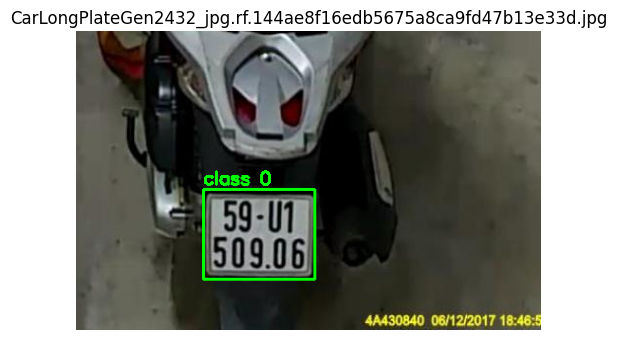

In [ ]:
IMG_DIR = Path("/content/drive/MyDrive/Plates/images/train")
LBL_DIR = Path("/content/drive/MyDrive/Plates/labels/train")

# Choose a random image
img_path = random.choice(list(IMG_DIR.glob("*.jpg")))
lbl_path = LBL_DIR / (img_path.stem + ".txt")

print("Image:", img_path.name, "| Label file:", lbl_path.name)

# Load image


# Read YOLO label(s) and draw boxes

# Display


# 3  Try to use OpenCV and Tesseract to read a plate


Chosen image: /content/drive/MyDrive/Plates/car.png


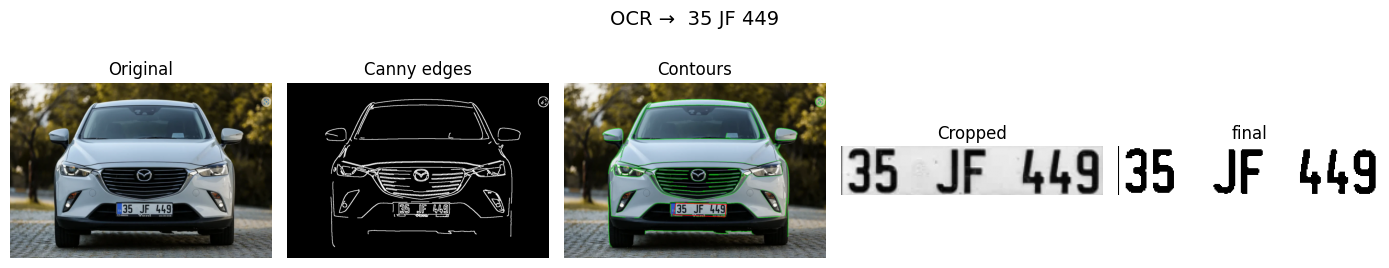

OCR text: 35 JF 449


In [ ]:
#First we try we an easy face car.

img_path="/content/drive/MyDrive/Plates/car.png"
print(f"Chosen image: {img_path}")    # Load the image
image = cv2.imread(img_path)
rgb    = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#



# Edge detection (Canny) to highlight plate contours


# Find contours to locate the license plate

# Sort contours based on area (descending order)



# Copy for drawing

# Draw all contours in green

# If plate contour is found, draw it in red and thicker


# Apply thresholding to binarize the plate area

# Perform OCR on the detected plate area




**This was an "easy" image, but even for this one, you see how you need to have good plate detection and then how you need to carefully clean the cropped area to use an OCR**

# 4 Plate detection using YOLO

First create a YAML file which contains:

- Where the data is
- How many classes there are
- What the class names are
**texte en gras**



In [ ]:
# data.yaml

yaml_content = """
path: /content/drive/MyDrive/Plates

train: images/train
val:   images/valid
test:  images/test

nc: 1
names: ['license_plate']
"""
yaml_dir = "/content/drive/MyDrive/Plates/"
os.makedirs(yaml_dir, exist_ok=True)

with open(os.path.join(yaml_dir, "data.yaml"), "w") as f:
    f.write(yaml_content.strip())





In [ ]:
from ultralytics.data.utils import check_det_dataset
check_det_dataset("/content/drive/MyDrive/Plates/data.yaml")


100%|██████████| 755k/755k [00:00<00:00, 23.3MB/s]


{'path': PosixPath('/content/drive/MyDrive/Plates'),
 'train': '/content/drive/MyDrive/Plates/images/train',
 'val': '/content/drive/MyDrive/Plates/images/valid',
 'test': '/content/drive/MyDrive/Plates/images/test',
 'nc': 1,
 'names': {0: 'license_plate'},
 'yaml_file': '/content/drive/MyDrive/Plates/data.yaml',
 'channels': 3}

# 5 Train your model

Options:

- epochs	Total training loops (we use 20 to go faster)
- imgsz		Input image size (smaller = faster, but may reduce accuracy, 640)
- batch	Number of images processed in parallel (try 8, 16, 32)
- optimizer		Optimization method (SGD, Adam, AdamW)
- project		Output folder where logs and weights go
- name Name of the run inside the project folder


In [ ]:
model = YOLO('yolov8n.pt')
print(model.device)

100%|██████████| 6.25M/6.25M [00:00<00:00, 250MB/s]

cpu


In [ ]:
import time
# Load the base YOLOv8 model
model = YOLO('yolov8n.pt')
# Measure training time
start = time.time()


1. **What effect does increasing `imgsz` have on:**
   - A. Accuracy
   - B. GPU usage
   - C. Training time

2. **What optimizer did you choose (`SGD`, `Adam`, or `AdamW`)?**
   - Why do you think it performs differently?

3. **What happens if you increase `batch` size too much on a small GPU?**
   - Hint: What kind of error might you get?

4. **How would you train longer and get better performance without overfitting?**
   - Suggest at least 2 ideas.

 # 6 Look at your results

 Your model has trained and stored its outputs in:

 /content/drive/MyDrive/runs_lp/yolov8n_lp/


Inside this folder, you will find:

- weights/ → Best and last model checkpoints.

- results.csv → Metrics logged at each epoch.


 **Questions:**

1. What images were saved during training? Open one of the train_batch0.jpg, train_batch1.jpg files. What do you see?

2. What is the difference between:

- weights/best.pt

- weights/last.pt

In [ ]:
!ls /content/drive/MyDrive/runs_lp/yolov8n_lp3/

args.yaml			 PR_curve.png	   val_batch0_labels.jpg
confusion_matrix_normalized.png  R_curve.png	   val_batch0_pred.jpg
confusion_matrix.png		 results.csv	   val_batch1_labels.jpg
F1_curve.png			 results.png	   val_batch1_pred.jpg
labels_correlogram.jpg		 train_batch0.jpg  val_batch2_labels.jpg
labels.jpg			 train_batch1.jpg  val_batch2_pred.jpg
P_curve.png			 train_batch2.jpg  weights


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path("/content/drive/MyDrive/runs_lp/yolov8n_lp3")
df = pd.read_csv(RUN_DIR / "results.csv")
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,160.155,1.38101,1.10615,1.27867,0.89710,0.81968,0.87836,0.48969,1.50338,1.00451,1.31351,0.070077,0.003325,0.003325
1,2,305.535,1.33539,0.85591,1.26004,0.95871,0.88334,0.93698,0.59861,1.33510,0.85732,1.24057,0.039418,0.005999,0.005999
2,3,446.341,1.28169,0.77653,1.23397,0.92773,0.88913,0.93518,0.60850,1.26583,0.73845,1.19626,0.008099,0.008013,0.008013
3,4,587.761,1.23667,0.71491,1.19429,0.91795,0.87989,0.91793,0.60791,1.22790,0.97038,1.22027,0.007030,0.007030,0.007030
4,5,728.903,1.21352,0.66564,1.16846,0.96682,0.91837,0.95738,0.63521,1.24744,0.64608,1.15712,0.006040,0.006040,0.006040


**Task: Fit & Plot the Evolution of Box Loss**

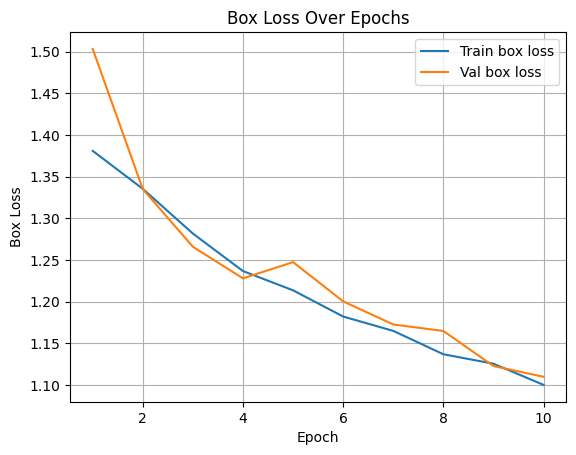

**Questions:**

* What general trend do you see in box loss?
* Does the validation loss decrease at the same rate?
* Is there any gap between training and validation loss?
* What might a large gap indicate?

mAP@0.5 means:

Mean Average Precision when IoU threshold = 0.5.
That is, a predicted box counts as correct if it overlaps the ground truth by at least 50%

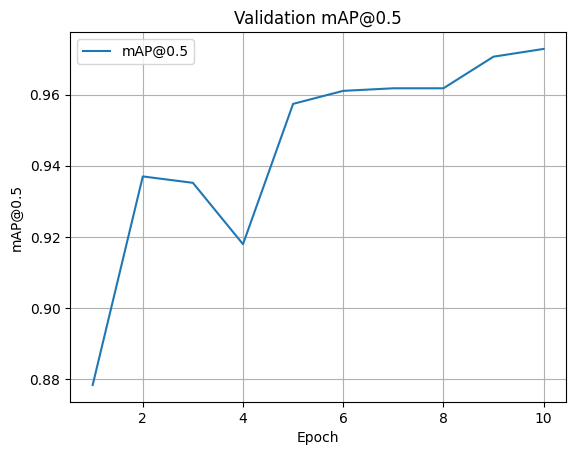

**Questions:**

* What does a high mAP@0.5 mean in object detection?
* At what epoch does it peak?
* Does it plateau or decline? What does that tell you?

**Task: Plot Precision & Recall over Epochs**

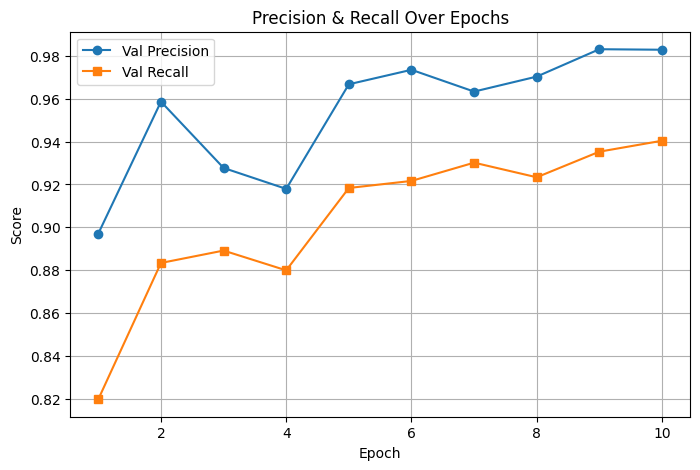

**Questions:**

* Do precision and recall improve together?
* Identify any trade-off epoch where one rises and the other falls.

# 6 Evaluate on Test Set, Examine Metrics, then Visualise Detections



In [ ]:
 #Load the best model

RUN_DIR = Path("/content/drive/MyDrive/runs_lp/yolov8n_lp3")
BEST_W  = RUN_DIR / "weights" / "best.pt"

model = YOLO(str(BEST_W))

#Evaluate on the *test* split
metrics = model.val(
    data="/content/drive/MyDrive/Plates/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,          # save PR_curve.png, confusion_matrix.png, etc.
    save_json=False       # optional: save COCO-style json for external eval
)



Test-set metrics:
Precision       : 0.9954
Recall          : 0.9518
mAP@0.5         : 0.9849
mAP@0.5:0.95    : 0.7011


**Visualization**

* Show prediction vs truth for a random image











Chosen image: /content/drive/MyDrive/Plates/images/test/xemay574_jpg.rf.1585810f2c9ce8a7e11c2f6f63b90f1d.jpg

image 1/1 /content/drive/MyDrive/Plates/images/test/xemay574_jpg.rf.1585810f2c9ce8a7e11c2f6f63b90f1d.jpg: 416x640 1 license_plate, 125.7ms
Speed: 2.6ms preprocess, 125.7ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)


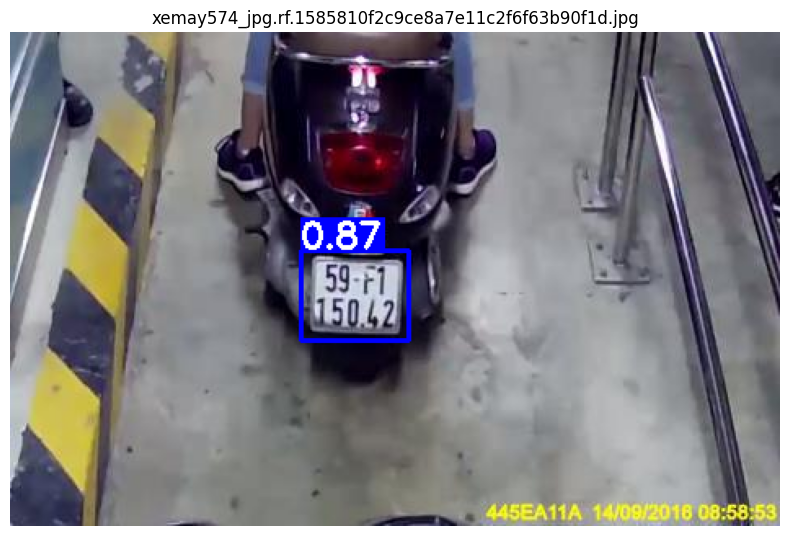

In [ ]:
#Choose ONE random test image
test_dir   = "/content/drive/MyDrive/Plates/images/test"
all_images = glob.glob(f"{test_dir}/*.*")  # jpg/png/…

random_idx = random.randrange(len(all_images))   # pick by index
img_path   = all_images[random_idx]

print(f"Chosen image: {img_path}")

# Load YOLO model and run inference on that single file
RUN_DIR = Path("/content/drive/MyDrive/runs_lp/yolov8n_lp3")
BEST_W  = RUN_DIR / "weights" / "best.pt"
model   = YOLO(BEST_W)
result  = model(img_path, conf=0.25)[0]          # a single Results object

#  Read the image with OpenCV
img = cv2.imread(img_path)
h,  w, _ = img.shape

# Draw a box function
def draw_box(im, x1, y1, x2, y2, color, label=None):
    cv2.rectangle(im, (x1, y1), (x2, y2), color, 2)
    if label:
        t_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
        cv2.rectangle(im, (x1, y1 - t_size[1] - 4), (x1 + t_size[0], y1), color, -1)
        cv2.putText(im, label, (x1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

# Draw ground-truth boxes
label_dir  = Path("/content/drive/MyDrive/Plates/labels/test") / Path(img_path).parent.name
label_file = label_dir / f"{Path(img_path).stem}.txt"

if label_file.exists():
    with open(label_file) as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
            draw_box(img, x1, y1, x2, y2, (0, 255, 0), "GT")

# Draw predicted boxes
for xyxy, conf in zip(result.boxes.xyxy.cpu().numpy(),
                      result.boxes.conf.cpu().numpy()):
    x1, y1, x2, y2 = map(int, xyxy)
    draw_box(img, x1, y1, x2, y2, (255, 0, 0), f"{conf:.2f}")

# Show the final image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(Path(img_path).name)
plt.axis("off")
plt.tight_layout()
plt.show()


**Questions**

* What are the test-set precision, recall, and mAP@0.5?
* Compare these with the best validation numbers. Are they similar? Why/why not?
* Looking at the P-R curve, is there a threshold where precision drops sharply?
* If recall is high but precision low, what adjustments could you make?

# 7 APPLY OCR Tesseract on Detected License Plates


**Be careful, Tesseract is very sensitive to the rotation**

Use "rotatequandoi14_jpg.rf.6dad288d912184b462409c102d4e50cf.jpg" and try
to read the plate using Pytessract.

Try to rotate the plate and see if it is better.

To rotate, use the cropped image and try detect edge, use CLAHE, denoise, thresh, hough line.

Look at all the angles


    4) look at all the angles
    angles = []
    lengths = []
    for x1, y1, x2, y2 in segs[:, 0]:
        dx, dy  = x2 - x1, y2 - y1
        length  = np.hypot(dx, dy)
        angle   = np.degrees(np.arctan2(dy, dx))  # [-180,180]
        #  [-45,45]
        angle = ((angle + 45) % 90) - 45
        angles.append(angle)
        lengths.append(length)


You can make some cut on the lengths to (keep np.percentile(lengths, 67) and as angle take the median


Then you have to clean the cropped images and read it.

Hints: it can be useful to seperate into 2 lines the plates

h = final.shape[0]

top   = final[:h//2, :]

bottom = final[h//2:, :]
  

Chosen image: /content/drive/MyDrive/Plates/images/test/rotatequandoi14_jpg.rf.6dad288d912184b462409c102d4e50cf.jpg

image 1/1 /content/drive/MyDrive/Plates/images/test/rotatequandoi14_jpg.rf.6dad288d912184b462409c102d4e50cf.jpg: 448x640 1 license_plate, 133.7ms
Speed: 2.6ms preprocess, 133.7ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


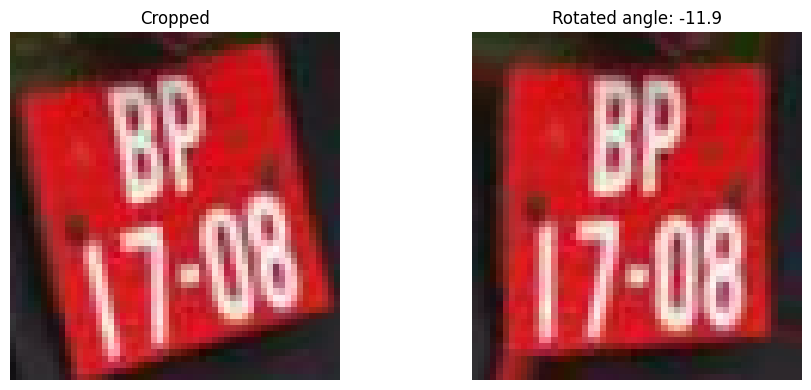

In [ ]:


img_path   = "/content/drive/MyDrive/Plates/images/test/rotatequandoi14_jpg.rf.6dad288d912184b462409c102d4e50cf.jpg"
print(f"Chosen image: {img_path}")

RUN_DIR = Path("/content/drive/MyDrive/runs_lp/yolov8n_lp3")
BEST_W  = RUN_DIR / "weights" / "best.pt"
model   = YOLO(BEST_W)
result  = model(img_path, conf=0.25)[0]          # a single Results object


Chosen image: /content/drive/MyDrive/Plates/images/test/rotatequandoi14_jpg.rf.6dad288d912184b462409c102d4e50cf.jpg

image 1/1 /content/drive/MyDrive/Plates/images/test/rotatequandoi14_jpg.rf.6dad288d912184b462409c102d4e50cf.jpg: 448x640 1 license_plate, 145.3ms
Speed: 2.8ms preprocess, 145.3ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Top row: BP
Bottom row: 17-08
Full plate: BP 17-08


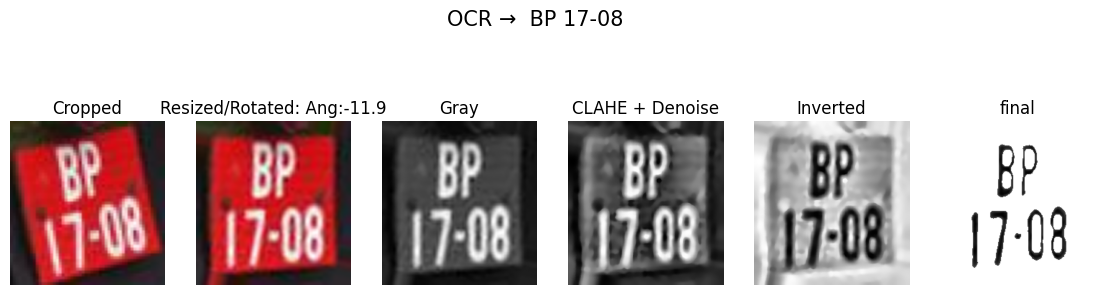

In [ ]:


img_path="/content/drive/MyDrive/Plates/images/test/rotatequandoi14_jpg.rf.6dad288d912184b462409c102d4e50cf.jpg"
print(f"Chosen image: {img_path}")

RUN_DIR = Path("/content/drive/MyDrive/runs_lp/yolov8n_lp3")
BEST_W  = RUN_DIR / "weights" / "best.pt"
model   = YOLO(BEST_W)
result  = model(img_path, conf=0.25)[0]          # a single Results object



**Try another random image from test**

Chosen image: /content/drive/MyDrive/Plates/images/test/CarLongPlateGen1490_jpg.rf.738f16de17e65e9532a8113a42e766aa.jpg

image 1/1 /content/drive/MyDrive/Plates/images/test/CarLongPlateGen1490_jpg.rf.738f16de17e65e9532a8113a42e766aa.jpg: 416x640 1 license_plate, 103.4ms
Speed: 1.6ms preprocess, 103.4ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 640)
Top row: PP
Bottom row: RV JII4U0J
Full plate: PP RV JII4U0J


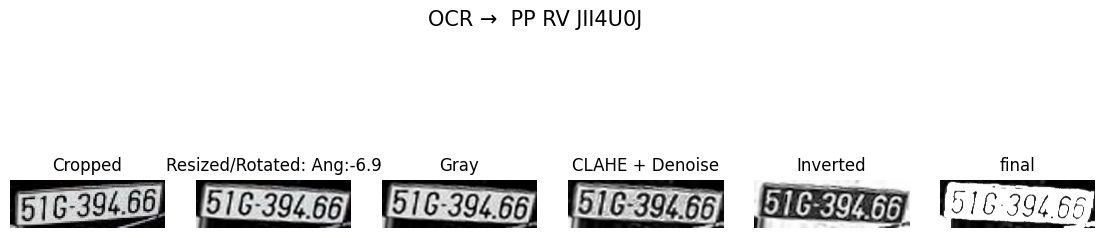

In [ ]:
test_dir   = "/content/drive/MyDrive/Plates/images/test"
all_images = glob.glob(f"{test_dir}/*.*")  # jpg/png/…

random_idx = random.randrange(len(all_images))   # pick by index
img_path   = all_images[random_idx]
img_path="/content/drive/MyDrive/Plates/images/test/CarLongPlateGen1490_jpg.rf.738f16de17e65e9532a8113a42e766aa.jpg"
print(f"Chosen image: {img_path}")

RUN_DIR = Path("/content/drive/MyDrive/runs_lp/yolov8n_lp3")
BEST_W  = RUN_DIR / "weights" / "best.pt"
model   = YOLO(BEST_W)
result  = model(img_path, conf=0.25)[0]          # a single Results object

# Read the image
img = cv2.imread(img_path)

for i, box in enumerate(result.boxes.xyxy.cpu().numpy()):
    x1, y1, x2, y2 = map(int, box)  # Convert float -> int

    # Crop the region of interest
    cropped = img[y1:y2, x1:x2]

rotated,ang=rot_img(cropped)


resized = cv2.resize(rotated, None, fx=4, fy=4, interpolation=cv2.INTER_CUBIC)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# DENOISE
denoised = cv2.bilateralFilter(enhanced, d=10, sigmaColor=20, sigmaSpace=20)

#Invert Thresh
inverted = cv2.bitwise_not(denoised)

final=denoised
# Get the minimum pixel value from the final image (grayscale)
min_val = 80

# Threshold: set all pixels < min_val to 0 (black), keep the rest
final = np.where(final > min_val, 255, final).astype(np.uint8)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
binary = cv2.morphologyEx(final, cv2.MORPH_CLOSE, kernel, iterations=1)
binary = cv2.dilate(binary, kernel, iterations=1)

# UPSCALE  (Tesseract likes tall chars)
h, w = binary.shape[:2]
final = cv2.resize(binary, (w * 10, h * 10), interpolation=cv2.INTER_NEAREST)

h = final.shape[0]
top   = final[:h//2, :]
bottom = final[h//2:, :]

cfg = "--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789:-"

top_txt    = pytesseract.image_to_string(top, config=cfg).strip()
bottom_txt = pytesseract.image_to_string(bottom, config=cfg).strip()

print("Top row:", top_txt)
print("Bottom row:", bottom_txt)
print("Full plate:", f"{top_txt} {bottom_txt}")


titles = ["Cropped", "Resized/Rotated: Ang:%0.1f"%ang, "Gray", "CLAHE + Denoise","Inverted","final"]
imgs   = [cropped, resized, gray, denoised,inverted,final]

plt.figure(figsize=(14,4))
for i,(im,t) in enumerate(zip(imgs,titles),1):
    plt.subplot(1,6,i)
    if len(im.shape)==2:
        plt.imshow(im, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(t); plt.axis('off')
plt.suptitle(f"OCR →  {top_txt} {bottom_txt}", fontsize=15)
plt.show()


As you can see, it is very difficult to read a random plate using Tesseract. Therefore, we will use now EASYOCR instead of Tesseract

In [ ]:
!pip install -q easyocr


In [ ]:
import easyocr
test_dir   = "/content/drive/MyDrive/Plates/images/test"
all_images = glob.glob(f"{test_dir}/*.*")  # jpg/png/…




image 1/1 /content/drive/MyDrive/Plates/images/test/CarLongPlateGen1490_jpg.rf.738f16de17e65e9532a8113a42e766aa.jpg: 416x640 (no detections), 187.2ms
Speed: 4.6ms preprocess, 187.2ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 640)


Original image: 61C.394.68   (conf: 0.44)
transformed image: 61G 394.66   (conf: 0.47)



image 1/1 /content/drive/MyDrive/Plates/images/test/xemay1258_jpg.rf.a589820acea6925e2aa2caf3f86752de.jpg: 416x640 1 license_plate, 100.5ms
Speed: 2.2ms preprocess, 100.5ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 640)


Original image: 60-V2   (conf: 0.45)
Original image: 2445]   (conf: 0.63)
transformed image: 60- Y2   (conf: 0.47)
transformed image: 2445   (conf: 0.86)


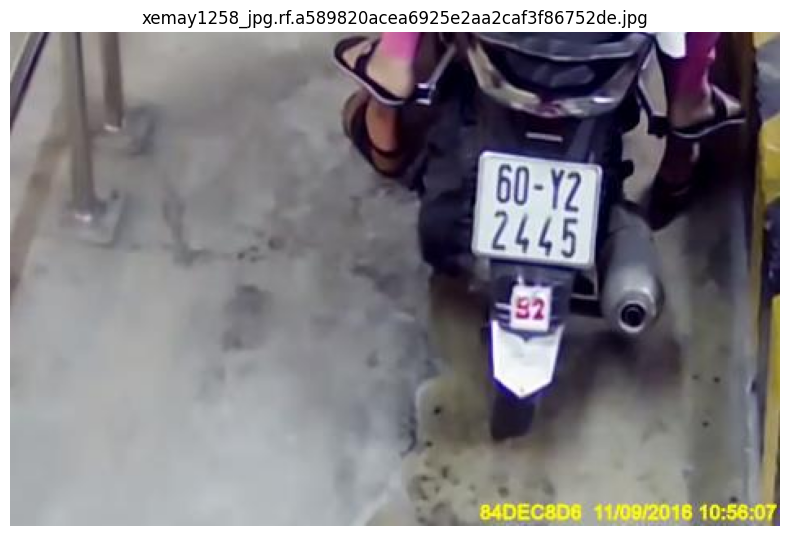

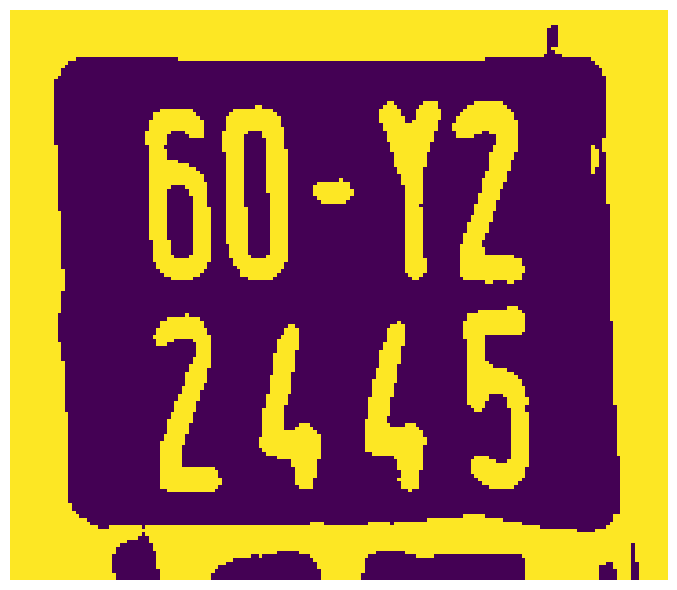

In [ ]:
import easyocr
test_dir   = "/content/drive/MyDrive/Plates/images/test"
all_images = glob.glob(f"{test_dir}/*.*")  # jpg/png/…

random_idx = random.randrange(len(all_images))   # pick by index
img_path   = all_images[random_idx]

RUN_DIR = Path("/content/drive/MyDrive/runs_lp/yolov8n_lp3")
BEST_W  = RUN_DIR / "weights" / "best.pt"
model   = YOLO(BEST_W)
result  = model(img_path, conf=0.25)[0]          # a single Results object

img = cv2.imread(img_path)

for i, box in enumerate(result.boxes.xyxy.cpu().numpy()):
    x1, y1, x2, y2 = map(int, box)  # Convert float -> int

    # Crop the region of interest
    cropped = img[y1:y2, x1:x2]

rotated,ang=rot_img(cropped)

resized = cv2.resize(rotated, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# DENOISE
denoised = cv2.bilateralFilter(enhanced, d=10, sigmaColor=20, sigmaSpace=20)

#Invert Thresh
_, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

final=thresh

# Run EasyOCR

reader = easyocr.Reader(['en'], gpu=True)
results = reader.readtext(final, detail=1, paragraph=False)

results2 = reader.readtext(cropped, detail=1, paragraph=False)

# Display and print
for (bbox, text, conf) in results2:
    print(f"Original image: {text}   (conf: {conf:.2f})")

for (bbox, text, conf) in results:
    print(f"transformed image: {text}   (conf: {conf:.2f})")

# Show the final image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(Path(img_path).name)
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(final)
plt.axis("off")
plt.tight_layout()
plt.show()